# 이미지 증강 (Data Augmentation)

- 이미지 증강 : 원본 이미지를 회전/이동/확대/밝기조정 등의 변형을 가해 **학습 데이터**를 인위적으로 늘리는 기법
- 이미지 증강 효과
    - 데이터 확장 : 500장 -> 매 Epoch 조금씩 다른 500장 이미지를 학습할 수 있음 -> 수천장을 본 효과
    - 불변성 학습 : 학습해야 하는 것들 중 모델이 무엇을 무시해야하고, 무엇을 찾아내야하는지 명확히 알려주는 효과
    - 정착화 (Regularization) 효과 : 모델이 특정 이미지 픽셀을 통째로 외우지 못하게 함 -> 과적합 현상 방지 (DropOut /L2규제와 같은 계열의 도구로써 사용)
- 이미지 증강에서 주의 사항 :
    - 학습 데이터에 대해서 적용 / 검증,평가 데이터에는 적용하지 않음
    - 증강된 이미지는 새로운 정보가 아님 / 같은 이미지 정보를 다르게 표현한 것일 뿐
    - 좌우 대칭 / 상하반전 -> 도메인에 따라 주의
- 이미지 증강 기법 종류
    - 기하 변환
        - 회전 (Rotation) : 이미지를 일정한 각도로 회전
        - 이동 (Translation) : 상하좌우 평행으로 이동
        - 확대/축소 (Zoom) : 일부를 확대하거나 축소
        - 반전 (Flip) : 좌우상하 뒤집기
        - 탄성 변형 (Elastic) : 격자를 비틀어서 변형
    - 강도 변환
        - 밝기 (Brightness) : 전체 픽셀값을 더하거나 빼서 밝기를 증폭,감쇠
        - 대비 (Contrast) : 밝고 어두움의 차이를 조정
        - 노이즈/블러 : 잡음 추가/ 흐리게 처리
    - 영역 변환
        - 일부 영역을 가림 (Random Erasing)
        - 두 이미지를 섞는 것 (Mixup / CutMix)

# 개별 미션

- 이미지 분류 -> 복부 CT 이미지내 장기 분류 모형생성 (다중분류) / 장기의 좌우 구분까지

- 11개의 장기 이미지를 분류 하기 위해, 전이학습 모형을 가져와 학습을 수행하고자 한다.
1. Train 폴더의 장기(클래스) 목록을 확인하고, 각 장기(클래스) 별 train / test 이미지 수를 표와 그래프로 시각화 하시오.

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import os
from google.colab import drive

In [2]:
# 폴더 경로를 호출
drive.mount('/content/drive', force_remount=True)
train_path = '/content/drive/MyDrive/ai 헬스케어 7기/의료 이미지 분석을 위한 컴퓨터 비전(CV)/03_OrganAMNIST/train/'
test_path  = '/content/drive/MyDrive/ai 헬스케어 7기/의료 이미지 분석을 위한 컴퓨터 비전(CV)/03_OrganAMNIST/test/'

Mounted at /content/drive


In [3]:
# 학습 데이터 폴더 내 파일 구조 확인
class_list = sorted(os.listdir(train_path))
class_list # 폴더 명이 곧 Y 클래스

['bladder',
 'femur-left',
 'femur-right',
 'heart',
 'kidney-left',
 'kidney-right',
 'liver',
 'lung-left',
 'lung-right',
 'pancreas',
 'spleen']

In [4]:
# 장기 별 이미지 개수를 각 클래스 별로 호출
count_list = [] # 각 장기 별 이미지 개수
for class_name in class_list:
    dict_add = {'class':class_name, 'train':len(os.listdir(train_path+class_name)), 'test':len(os.listdir(test_path+class_name))}
    count_list.append(dict_add)
# 딕셔너리 형태로 변환하는 이유는 Pandas 라이브러리의 DataFrame으로 변환하기 쉽기 때문

In [5]:
df_count = pd.DataFrame(count_list)
df_count

,class,train,test
0,bladder,500,200
1,femur-left,500,200
2,femur-right,500,200
3,heart,500,200
4,kidney-left,500,200
5,kidney-right,500,200
6,liver,500,200
7,lung-left,500,200
8,lung-right,500,200
9,pancreas,500,200


In [6]:
px.bar(df_count, x='class', y=['train','test'], barmode='group')
# 학습데이터와 검증데이터의 비율 차이 5:2
# 원본 OrganAMNIST 각 장기별로 이미지의 개수의 차이가 큼

2. 이미지 불러와 아래의 절차를 따라, 데이터를 처리하는 함수를 구성하시오.
    - 이미지를 배열로 변환하여 X값을 구성
    - X 값의 각 픽셀 값을 0~1사이 값으로 정규화
    - 폴더 명을 활용해, Label (Y) 값을 구성

In [7]:
from PIL import Image
import tensorflow as tf
from keras.preprocessing import image

In [8]:
# 한장의 이미지를 호출
image_path = train_path + 'liver/'
file_name_list = os.listdir(image_path)
file_name_list[0]

'train_00006_liver.png'

In [9]:
# 폴더 내 이미지 하나를 출력
image1 = Image.open(image_path + file_name_list[0]) # 폴더 내 이미지 호출
image_array = image.img_to_array(image1) # 이미지가 배열로 변환
image_array.shape

(64, 64, 1)

In [10]:
image_array_scale = image_array/255 # 이미지에 대한 정규화
image_array_scale

array([[[0.        ],
        [0.        ],
        [0.        ],
        ...,
        [0.        ],
        [0.        ],
        [0.        ]],

       [[0.        ],
        [0.        ],
        [0.        ],
        ...,
        [0.        ],
        [0.        ],
        [0.        ]],

       [[0.        ],
        [0.        ],
        [0.        ],
        ...,
        [0.2       ],
        [0.01176471],
        [0.        ]],

       ...,

       [[0.21960784],
        [0.4392157 ],
        [0.5529412 ],
        ...,
        [0.44313726],
        [0.54901963],
        [0.5803922 ]],

       [[0.2       ],
        [0.2784314 ],
        [0.49411765],
        ...,
        [0.40784314],
        [0.5411765 ],
        [0.54509807]],

       [[0.2       ],
        [0.24705882],
        [0.43137255],
        ...,
        [0.43137255],
        [0.5411765 ],
        [0.5568628 ]]], dtype=float32)

In [11]:
# 이미지 처리 함수를 함수형태로 구성
from sklearn.utils import shuffle

In [12]:
# 클래스 별 이미지의 특정 개수만큼 호출하는 파트를 추가 -> 이미지 증강
# 이미지 증강없이 학습 한 모형 성능 VS 이미지 증강으로 학습 한 모형 성능 비교
def image_to_tensor_organ(base_path, n_per_class=None):
    # n_per_class : 특정 값을 지정하지 않는다면, 모든 데이터를 호출 / 숫자를 입력하면 해당 숫자만큼 데이터를 호출
    image_list = [] # 이미지를 텐서로 변환한 X 값을 넣을 리스트
    label_list = [] # 각 이미지의 정답을 담을 리스트

    # 각각 폴더 내 파일명을 리스트로 구성
    for label, class_name in enumerate(class_list):
        folder_path = base_path + class_name + '/' # 데이터 호출을 위한 경로
        file_name_list = sorted(os.listdir(folder_path)) # 폴더 내 파일명을 정렬 후 리스트로 선언

        # [이미지 증강]을 위해 이미지의 특정 개수를 호출 해 올 수 있도록 제한
        if n_per_class is not None : # 이미지 개수를 따로 지정하지 않았다면 아래 종속구문을 건너뜀
            # n_per_class 에 숫자값 (특정 이미지 개수를 추출하기로 했다면)을 넣었다면 아래 코드가 실행
            file_name_list = file_name_list[:n_per_class]

        # 이미지 변환 및 X/Y를 구성
        for file_name in file_name_list:
            image1 = Image.open(folder_path + file_name)
            image_array = image.img_to_array(image1)
            # ResNet 모형에 이미지를 넣을 때 정규화
            image_list.append(image_array)
            label_list.append(label)

    # 변환된 데이터가 있는 리스트값을 X와 Y로 선언
    X = tf.stack(image_list).numpy()
    Y = np.array(label_list)
    return shuffle(X,Y,random_state=1234)

In [13]:
# 학습 데이터 구성  -> 각 클래스 별로 이미지 증강을 위해 200장만 호출하여 구성
# 2,200 장 학습 데이터가 구성
X_train, Y_train = image_to_tensor_organ(train_path, n_per_class=200)
print(X_train.shape)
print(Y_train.shape)

(2200, 64, 64, 1)
(2200,)


In [14]:
# 검증 데이터 : 전체 데이터 활용
X_test, Y_test = image_to_tensor_organ(test_path)
print(X_test.shape)
print(Y_test.shape)

(2200, 64, 64, 1)
(2200,)


3. Scikit-Learn 라이브러리를 활용해 기존 머신러닝 기법(RandomForest)으로 11개 장기를 분류하고 성능을 평가하시오.

In [15]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline      import make_pipeline
from sklearn.ensemble      import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics  import classification_report

In [16]:
# 이미지를 2차원 (표본수 / 픽셀 값)으로 펴서 머신러닝 학습 수행
X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat  = X_test.reshape(len(X_test), -1)

In [17]:
model_pipe = make_pipeline(MinMaxScaler(), RandomForestClassifier())

In [18]:
hyper = {'randomforestclassifier__n_estimators':[100],
        'randomforestclassifier__max_depth':[3,4,5],
        'randomforestclassifier__random_state':[1234]}
grid_model = GridSearchCV(model_pipe, param_grid=hyper, cv=3, n_jobs=-1, scoring='accuracy')
grid_model.fit(X_train_flat, Y_train)
best_model = grid_model.best_estimator_

In [19]:
Y_train_pred = best_model.predict(X_train_flat)
Y_test_pred = best_model.predict(X_test_flat)

In [20]:
print(classification_report(Y_train, Y_train_pred))

              precision    recall  f1-score   support

           0       0.42      0.93      0.58       200
           1       0.93      0.69      0.79       200
           2       0.95      0.73      0.82       200
           3       1.00      0.96      0.98       200
           4       0.69      0.22      0.33       200
           5       0.48      0.64      0.55       200
           6       0.87      0.83      0.85       200
           7       0.97      0.99      0.98       200
           8       0.99      0.98      0.99       200
           9       0.61      0.56      0.58       200
          10       0.70      0.55      0.61       200

    accuracy                           0.73      2200
   macro avg       0.78      0.74      0.73      2200
weighted avg       0.78      0.73      0.73      2200



In [21]:
print(classification_report(Y_test, Y_test_pred))

              precision    recall  f1-score   support

           0       0.34      0.94      0.50       200
           1       0.87      0.55      0.67       200
           2       0.95      0.61      0.74       200
           3       0.98      0.82      0.89       200
           4       0.45      0.13      0.20       200
           5       0.34      0.47      0.39       200
           6       0.80      0.73      0.77       200
           7       0.82      0.85      0.84       200
           8       0.92      0.90      0.91       200
           9       0.41      0.32      0.36       200
          10       0.43      0.32      0.37       200

    accuracy                           0.60      2200
   macro avg       0.66      0.60      0.60      2200
weighted avg       0.66      0.60      0.60      2200



- 해당 데이터는 다중 분류 이미지임에도 불구하고, 이미지의 특성이 다르고, 사이즈가 작아 차원의 저주 문제를 보완 (2,200 row x 4,096 Column)
- 해당 데이터에 좌/우 쌍을 구분하는 클래스는 여전히 한계가 명확
- 다중 분류에서 클래스가 많은경우, 혼동행렬(Confusion Matrix)같이 확인

4. 앞서 만든 모형의 성능을 혼동행렬(Confusion Matrix)로 평가하시오.

In [22]:
from sklearn.metrics import confusion_matrix

In [23]:
cm = confusion_matrix(Y_test, Y_test_pred)
cm

array([[188,   0,   0,   0,   0,   3,   0,   4,   3,   2,   0],
       [ 44, 109,   4,   0,   3,  18,   0,   3,   0,  17,   2],
       [ 38,  12, 122,   0,   3,  11,   0,   0,   2,   9,   3],
       [  0,   0,   0, 164,   0,   5,  12,  13,   0,   0,   6],
       [ 68,   1,   1,   3,  26,  43,   0,  10,   3,  18,  27],
       [ 70,   0,   1,   0,   0,  95,   3,   1,   2,  19,   9],
       [ 12,   0,   0,   0,   0,  29, 147,   1,   1,   1,   9],
       [  9,   0,   0,   0,   4,   4,   4, 170,   5,   2,   2],
       [  1,   0,   0,   0,   2,   2,   6,   2, 179,   0,   8],
       [ 63,   0,   0,   0,   5,  41,   8,   0,   0,  63,  20],
       [ 58,   4,   0,   0,  15,  32,   3,   3,   0,  21,  64]])

In [24]:
fig1 = px.imshow(cm, x=class_list, y=class_list, text_auto=True, labels={'x':'예측값', 'y':'실제값', 'color':'건수'})
fig1.update_layout(width=600, height=600)

5. ResNet50 알고리즘을 이용해 앞서 처리한 데이터를 학습하고 평가를 수행하시오.

In [25]:
from keras.applications import ResNet50
from keras.applications.resnet50 import preprocess_input
from keras.models import Sequential
from keras.layers import BatchNormalization
from keras.layers import Activation
from keras.layers import GlobalAveragePooling2D
from keras.layers import Dense
from keras.layers import Dropout

In [26]:
X_train.shape

(2200, 64, 64, 1)

In [27]:
# ResNet50 입력 조건에 맞춰 데이터를 재 구성
# 크기 : 64x64 그대로 ResNet에 입력 (224x224)
# 채널 : Intensity -> RGB
X_train_R = preprocess_input( np.repeat(X_train, 3, axis=-1 ) )
X_test_R  = preprocess_input( np.repeat(X_test, 3, axis=-1 ) )

In [28]:
# 사전 학습된 ResNet50 호출 / Convolution 부분을 동결 (특성추출 방식)
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(64,64,3))
base_model.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [29]:
model_ResNet = Sequential()
model_ResNet.add( base_model )
model_ResNet.add( GlobalAveragePooling2D() )
model_ResNet.add( Dense(128, use_bias=False, kernel_initializer='he_normal'))
model_ResNet.add( BatchNormalization())
model_ResNet.add( Activation('relu'))
model_ResNet.add( Dropout(0.5))
model_ResNet.add( Dense(len(class_list), activation='softmax'))

model_ResNet.compile(optimizer='adam',loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_ResNet.fit(X_train_R, Y_train, epochs=10, validation_split=0.2, batch_size=64)

Epoch 1/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.6085 - loss: 1.2039 - val_accuracy: 0.7750 - val_loss: 0.6561
Epoch 2/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.8381 - loss: 0.5134 - val_accuracy: 0.8614 - val_loss: 0.3639
Epoch 3/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.8932 - loss: 0.3670 - val_accuracy: 0.9159 - val_loss: 0.2643
Epoch 4/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.9278 - loss: 0.2731 - val_accuracy: 0.9409 - val_loss: 0.2294
Epoch 5/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.9500 - loss: 0.2191 - val_accuracy: 0.9409 - val_loss: 0.2116
Epoch 6/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.9665 - loss: 0.1692 - val_accuracy: 0.9318 - val_loss: 0.2192
Epoch 7/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.9693 - loss: 0.1406 - val_accuracy: 0.9386 - val_loss: 0.2113
Epoch 8/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.9739 - loss: 0.1228 - val_accuracy: 0.9455 - val_loss:

In [30]:
Y_test_pred_R = model_ResNet.predict(X_test_R, verbose=0).argmax(axis=1)

In [31]:
print(classification_report(Y_test, Y_test_pred_R, target_names=class_list))

              precision    recall  f1-score   support

     bladder       0.86      0.76      0.81       200
  femur-left       0.98      0.82      0.89       200
 femur-right       0.85      0.94      0.89       200
       heart       0.99      0.88      0.93       200
 kidney-left       0.61      0.60      0.61       200
kidney-right       0.69      0.73      0.71       200
       liver       0.94      0.97      0.96       200
   lung-left       0.94      0.96      0.95       200
  lung-right       1.00      0.94      0.97       200
    pancreas       0.89      0.95      0.92       200
      spleen       0.75      0.88      0.81       200

    accuracy                           0.86      2200
   macro avg       0.86      0.86      0.86      2200
weighted avg       0.86      0.86      0.86      2200



In [32]:
cm_R = confusion_matrix(Y_test, Y_test_pred_R)

In [33]:
fig1 = px.imshow(cm_R, x=class_list, y=class_list,
                text_auto=True,
                labels={'x':'예측', 'y':'실제', 'color':'건수'})
fig1.update_layout(width=600,height=600)

In [35]:
model_ResNet.save('/content/drive/MyDrive/ai 헬스케어 7기/의료 이미지 분석을 위한 컴퓨터 비전(CV)/03_OrganAMNIST/03_ResNet_Model.keras')

- 이미지 증강 시 주의사항
    1. 좌우반전 (Horizontal Flip) : 좌우가 바뀔때, 판단이 달라지는 경우 주의
    2. 과도한 회전 : 회전 증강 적용 시 주의
    3. 강도 변환 : CT이미지의 밝기는 물리적 단위 -> HU / 밝기 조정 대신 Window Jittering / HU 화면 밝기로 변환하는 Window 구성하여 중심폭을 변환

- 증강의 방법
    1. 사전 증강 (Offline) : 이미지 증강본을 미리 만들어 저장 -> 학습 시 속도가 빨라짐/ Epoch 같은 증강본을 반복해서 학습
    2. 실시간 증강 (Online) : 배치가 만들어질 때 마다 즉석으로 변형 -> 매 Epoch 마다 다른 이미지를 학습
        - 증강 Layer를 모델에 가장 앞부분에 배치

In [36]:
# 소량 데이터에서 이미지 증강할 때 성능의 차이가 발생하는가?
X_small, Y_small = image_to_tensor_organ(train_path, n_per_class=50) # 각 클래스 별 50장 -> 550장 학습 데이터가 구성
print(X_small.shape)
print(Y_small.shape)

(550, 64, 64, 1)
(550,)


In [37]:
import keras
from keras import layers
from keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout

In [38]:
# 이미지 증강을 적용할 수 있는 CNN 알고리즘을 구성
# augmentation_layer=None / 이미지 증강을 선택적으로 넣을 수 잇는 파라미터를 설정
def build_cnn_model(augmentation_layer=None, model_name='CNN'):
    model = Sequential(name=model_name)
    model.add( keras.Input(shape=(64,64,1)) )
    if augmentation_layer is not None: # 이미지 증강을 수행한다고 할 때, 아래의 이미지 증강 Layer를 추가
        model.add( augmentation_layer )
    # 증강 이후 정규화 수행 : 0 ~ 1
    model.add( layers.Rescaling(1./255) )
    # CNN 알고리즘을 적용시켜 학습 수행
    model.add( Conv2D(32, (3,3), activation='relu') )
    model.add( MaxPool2D(pool_size=(2,2)) )
    model.add( Conv2D(32, (3,3), activation='relu') )
    model.add( MaxPool2D(pool_size=(2,2)) )
    # Fully Connected Layer
    model.add( Flatten() )
    model.add( Dense(128, activation='relu') )
    model.add( Dropout(0.5) )
    model.add( Dense(len(class_list), activation='softmax') )
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [39]:
model_CNN = build_cnn_model()
model_CNN.summary()

Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 11)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 813,931 (3.10 MB)

 Trainable params: 813,931 (3.10 MB)

 Non-trainable params: 0 (0.00 B)

In [40]:
# 이미지 증강에 사용할 Layer 구성
# 좌우 반전 증강은 제외 / 강도 변환은 약하게 수행
augmentation = Sequential([
    # 회전 증강 (0.03 x 360 = 10.8도 내에서 Random하게 회전)
    # 회전/이동을 하다보면 특정 위치에 공백이 발생 -> 특정 상수로 채워 넣음 (fill_mode='constant')
    # 회전에서 발생한 공백을 0으로 채워 넣음 (fill_value=0.0)
    layers.RandomRotation(0.03, fill_mode='constant', fill_value=0.0, seed=1234),
    # 이동 증강 (가로/세로 6%내 평행 이동 )
    layers.RandomTranslation(0.06, 0.06, fill_mode='constant', fill_value=0.0, seed=1234),
    # 확대 또는 축소 증강 (10% 축소하거나 확대)
    layers.RandomZoom(0.10, fill_mode='constant', fill_value=0.0, seed=1234),
    # 명암 대비 증강 (10% 세거나 적어짐)
    layers.RandomContrast(0.10, value_range=(0,255), seed=1234),
    # 밝기를 -12.75픽셀 ~ + 12.75픽셀 증강
    layers.RandomBrightness(0.05, value_range=(0,255), seed=1234),
], name='augmentation')

augmentation.summary()

Model: "augmentation"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_rotation                 │ ?                      │   0 (unbuilt) │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ ?                      │   0 (unbuilt) │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ ?                      │   0 (unbuilt) │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_brightness               │ ?                      │   0 (unbuilt) │
│ (RandomBrightness)              │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [41]:
import matplotlib.pyplot as plt

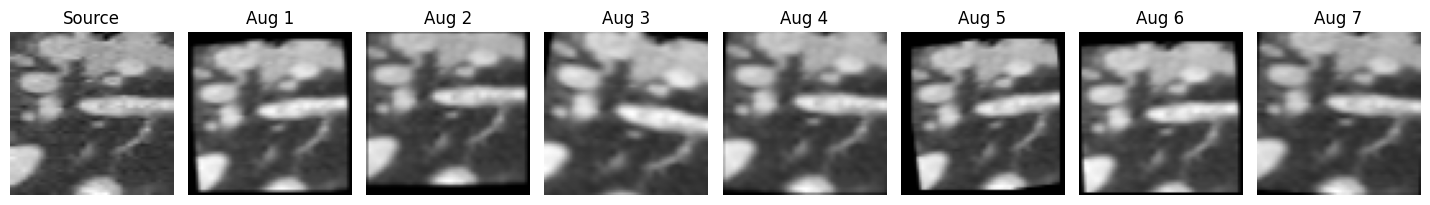

In [42]:
def show_augmentation(img_array, aug_layer, n=7):
    fig, axes = plt.subplots(1, n+1, figsize=(1.8*(n+1), 2.4))

    axes[0].imshow(img_array[:,:,0], cmap='gray')
    axes[0].set_title('Source')
    axes[0].axis('off')

    for i in range(1, n+1):
        out = aug_layer(np.expand_dims(img_array, axis=0), training=True)
        out = keras.ops.convert_to_numpy(out)[0]
        axes[i].imshow(np.clip(out,0,255)[:,:,0], cmap='gray')
        axes[i].set_title('Aug ' + str(i))
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

show_augmentation(X_train[0], augmentation)
# 실제 하나의 이미지를 증강 적용했을 때 나오는 결과
# 하나의 이미지를 여러차례 걸쳐 증강을 수행 (7번의 증강을 반복해 수행 )

In [43]:
# 1. 증강 없이 학습을 수행
model_no_aug = build_cnn_model(augmentation_layer=None, model_name='CNN_no_aug')
hist_no_aug = model_no_aug.fit(X_small, Y_small, epochs=40, validation_split=0.2, batch_size=32)

Epoch 1/40
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 246ms/step - accuracy: 0.1750 - loss: 2.3509 - val_accuracy: 0.3636 - val_loss: 2.1944
Epoch 2/40
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 124ms/step - accuracy: 0.2705 - loss: 2.0335 - val_accuracy: 0.4727 - val_loss: 1.6943
Epoch 3/40
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 123ms/step - accuracy: 0.4114 - loss: 1.7283 - val_accuracy: 0.4182 - val_loss: 1.5986
Epoch 4/40
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 122ms/step - accuracy: 0.4364 - loss: 1.5567 - val_accuracy: 0.5727 - val_loss: 1.3386
Epoch 5/40
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 125ms/step - accuracy: 0.5182 - loss: 1.3554 - val_accuracy: 0.6091 - val_loss: 1.2041
Epoch 6/40
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 149ms/step - accuracy: 0.5705 - loss: 1.2228 - val_accuracy: 0.6182 - val_loss: 1.1213
Epoch 7/40
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 222ms/step - accuracy: 0.6386 - loss: 1.1572 - val_accuracy: 0.7000 - val_loss: 1.0954
Epoch 8/40
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step - accuracy: 0.6341 - loss: 1.0743 - val_accuracy: 0.

In [44]:
# 2. 증강을 수행
model_aug = build_cnn_model(augmentation_layer=augmentation, model_name='CNN_aug')
hist_aug = model_aug.fit(X_small, Y_small, epochs=40, validation_split=0.2, batch_size=32)
# 실시간 증강의 경우, 매번 Epoch을 수행할 때, 학습 데이터가 매번 달라짐 -> 증강모델은 수렴하기까지 조금 더 오래 걸림

Epoch 1/40
14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 316ms/step - accuracy: 0.1773 - loss: 2.3783 - val_accuracy: 0.3727 - val_loss: 2.1607
Epoch 2/40
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 253ms/step - accuracy: 0.2909 - loss: 2.0546 - val_accuracy: 0.4727 - val_loss: 1.7827
Epoch 3/40
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 180ms/step - accuracy: 0.3205 - loss: 1.8710 - val_accuracy: 0.4636 - val_loss: 1.6359
Epoch 4/40
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 135ms/step - accuracy: 0.3841 - loss: 1.7162 - val_accuracy: 0.5455 - val_loss: 1.4844
Epoch 5/40
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 133ms/step - accuracy: 0.4205 - loss: 1.6797 - val_accuracy: 0.5818 - val_loss: 1.4314
Epoch 6/40
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 135ms/step - accuracy: 0.4409 - loss: 1.5583 - val_accuracy: 0.5091 - val_loss: 1.4233
Epoch 7/40
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 134ms/step - accuracy: 0.4705 - loss: 1.4470 - val_accuracy: 0.6182 - val_loss: 1.1979
Epoch 8/40
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 231ms/step - accuracy: 0.5591 - loss: 1.2894 - val_accuracy: 0.

In [45]:
def evaluate_model(model, model_title):
    Y_pred = model.predict(X_test, verbose=0).argmax(axis=1)
    print('=' * 22, model_title, '=' * 22)
    print(classification_report(Y_test, Y_pred, target_names=class_list, zero_division=0))

evaluate_model(model_no_aug, '550장 / 증강 없음')
evaluate_model(model_aug,    '550장 / 증강 적용')

====================== 550장 / 증강 없음 ======================
              precision    recall  f1-score   support

     bladder       0.49      0.78      0.60       200
  femur-left       0.74      0.61      0.67       200
 femur-right       0.75      0.80      0.77       200
       heart       0.97      0.85      0.91       200
 kidney-left       0.48      0.39      0.43       200
kidney-right       0.55      0.42      0.48       200
       liver       0.72      0.72      0.72       200
   lung-left       0.89      0.80      0.84       200
  lung-right       0.84      0.86      0.85       200
    pancreas       0.63      0.69      0.66       200
      spleen       0.43      0.45      0.44       200

    accuracy                           0.67      2200
   macro avg       0.68      0.67      0.67      2200
weighted avg       0.68      0.67      0.67      2200

====================== 550장 / 증강 적용 ======================
              precision    recall  f1-score   support

     bladder  

- 이미지 증강의 경우 데이터가 적으면 적을수록 이미지 증강의 이득이 커짐 / 데이터가 충분하다면, 이득은 작아짐
- 증강은 부족한 데이터를 학습할 때, 정보의 손실을 완화하는 역할 / 데이터를 대체하는 수단은 아님 (학습 데이터에 대해서만 증강)

In [46]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

In [47]:
# 학습 곡선 비교 : 증강이 과적합을 억제하는지 확인
# 색상 = 증강 여부 (파랑 : 증강 X, 주황 : 증강 O) / 선 종류 = 학습(실선) vs 검증(점선)
COLOR_NO_AUG = 'blue'
COLOR_AUG    = 'red'

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=('Loss (학습과 검증의 간격이 좁을수록 과적합이 적음)',
                                    'Validation Accuracy'))

fig.add_trace(go.Scatter(y=hist_no_aug.history['loss'],     name='증강 X - 학습',
                         line=dict(color=COLOR_NO_AUG)),               row=1, col=1)
fig.add_trace(go.Scatter(y=hist_no_aug.history['val_loss'], name='증강 X - 검증',
                         line=dict(color=COLOR_NO_AUG, dash='dot')),   row=1, col=1)
fig.add_trace(go.Scatter(y=hist_aug.history['loss'],        name='증강 O - 학습',
                         line=dict(color=COLOR_AUG)),                  row=1, col=1)
fig.add_trace(go.Scatter(y=hist_aug.history['val_loss'],    name='증강 O - 검증',
                         line=dict(color=COLOR_AUG, dash='dot')),      row=1, col=1)

fig.add_trace(go.Scatter(y=hist_no_aug.history['val_accuracy'], name='증강 X - 검증 accuracy',
                         line=dict(color=COLOR_NO_AUG, dash='dot')),   row=1, col=2)
fig.add_trace(go.Scatter(y=hist_aug.history['val_accuracy'],    name='증강 O - 검증 accuracy',
                         line=dict(color=COLOR_AUG, dash='dot')),      row=1, col=2)

fig.update_xaxes(title_text='epoch')
fig.update_layout(width=1150, height=450)
fig.show()